### Задача 4
Смоделировать выборку объема 1000 из дискретного распределения на множестве цифр 0, 1, 2, ..., 9 с весами 0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2. По выборке построить гистограмму. Оптимизируйте алгоритм, упорядочив веса.

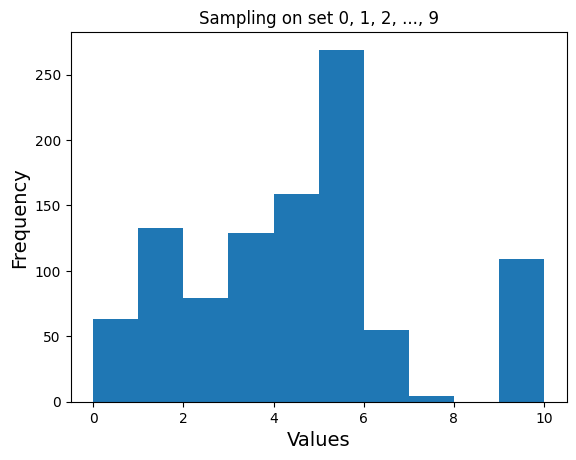

In [127]:
import numpy as np
import matplotlib.pyplot as plt

weights=np.array([0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2])
weights=weights/np.sum(weights)
a=np.zeros(1000)
for i in range(1000):
    r=np.random.rand()
    for k, j in enumerate(np.cumsum(weights)):
        if r<=j:
            a[i]=k
            break

plt.hist(a, np.arange(11))
plt.xlabel("Values", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.title("Sampling on set 0, 1, 2, ..., 9")
plt.show()

### Задача 5
Смоделируйте выборку размера 1000 из распределения $Exp(\lambda)$ с помощью метода Inverse transform. Постройте выборочную гистограмму и точный график плотности распределения.

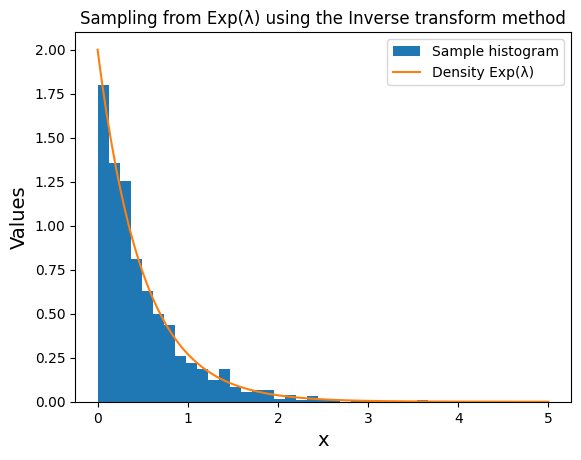

In [128]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

lambd=2
a=[-np.log(1-np.random.rand(1000))/lambd]

plt.hist(a, 30, density=True, label='Sample histogram')
plt.plot(np.linspace(0, 5, 100), expon.pdf(np.linspace(0, 5, 100), scale=1/lambd), label='Density Exp(λ)')
plt.xlabel('x', fontsize=14)
plt.ylabel('Values', fontsize=14)
plt.title('Sampling from Exp(λ) using the Inverse transform method')
plt.legend()
plt.show()

### Задача 6
Обоснуйте (устно), что метод accept-reject действительно производит выборку из нужного распределения. Смоделируйте 1000 точек из распределения с плотностью $e^xcos^2x$ на отрезке $[-\pi/2, \pi/2]$. По выборке постройте график выборочной гистограммы и сравните его с графиком точной функции плотности.

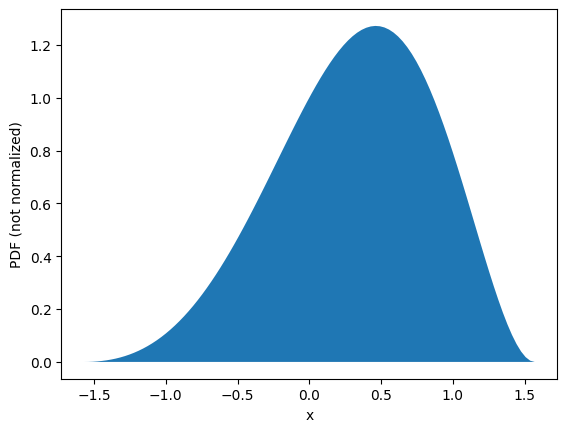

In [93]:
%matplotlib inline
fig = plt.figure()
fig.patch.set_facecolor('xkcd:white')

x = np.linspace(-np.pi/2, np.pi/2, 100)
density = np.exp(x)*np.cos(x)**2 # not normalized density!
plt.fill_between(x, 0, density)
plt.ylabel('PDF (not normalized)')
plt.xlabel('x')
plt.show()

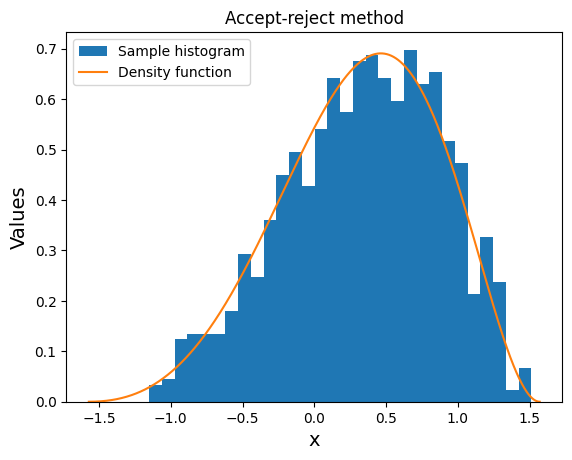

In [134]:
import numpy as np
import matplotlib.pyplot as plt

a=[]
while len(a)<1000:
    x=(np.random.rand()-0.5)*np.pi
    y=np.random.rand()
    if y<=np.exp(x)*np.cos(x)**2/np.trapz(np.exp((np.linspace(-np.pi/2, np.pi/2, 1000)))*np.cos(np.linspace(-np.pi/2, np.pi/2, 1000))**2, np.linspace(-np.pi/2, np.pi/2, 1000)):
        a.append(x)

plt.hist(a, 30, density=True, label='Sample histogram')
plt.plot(np.linspace(-np.pi/2, np.pi/2, 1000), np.exp(np.linspace(-np.pi/2, np.pi/2, 1000))*np.cos(np.linspace(-np.pi/2, np.pi/2, 1000))**2/np.trapz(np.exp((np.linspace(-np.pi/2, np.pi/2, 1000)))*np.cos(np.linspace(-np.pi/2, np.pi/2, 1000))**2, np.linspace(-np.pi/2, np.pi/2, 1000)), label='Density function')
plt.xlabel('x', fontsize=14)
plt.ylabel('Values', fontsize=14)
plt.title('Accept-reject method')
plt.legend()
plt.show()

### Задача 7
Смоделировать и изобразить выборку из 500 точек равномерно распределенных внутри данного треугольника без использования метода отбора.

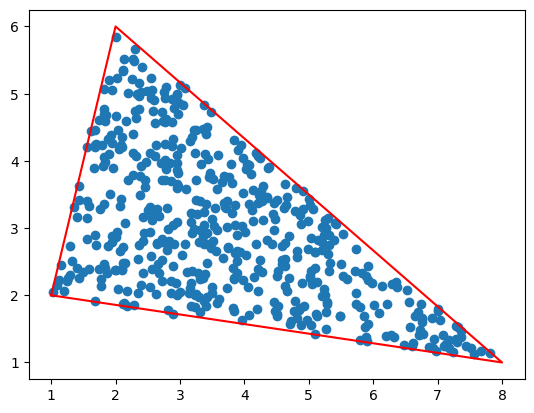

In [233]:
import numpy as np
import matplotlib.pyplot as plt

a=np.array([[1, 2], [2, 6], [8,1]])
b=np.zeros((500, 2))
for i in range(500):
  x=np.random.rand()
  y=np.random.rand()
  if (x+y>1):
    x=1-x
    y=1-y
  b[i]=a[0]+x*(a[1]-a[0])+y*(a[2]-a[0])

plt.scatter(b[:, 0], b[:, 1])
plt.plot([a[0][0], a[1][0], a[2][0], a[0][0]], [a[0][1], a[1][1], a[2][1], a[0][1]], 'r')
plt.show()

### Задача 8
Смоделировать без использования метода отбора выборку из 500 точек равномерно распределенных внутри единичного круга. Изобразите полученные точки. Они действительно равномерно заполняют круг?

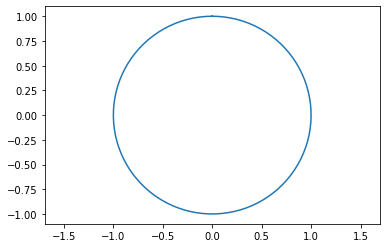

In [ ]:
%matplotlib inline
fig = plt.figure()
fig.patch.set_facecolor('xkcd:white')

t = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.sin(t), np.cos(t))
plt.axis('equal')
plt.show()

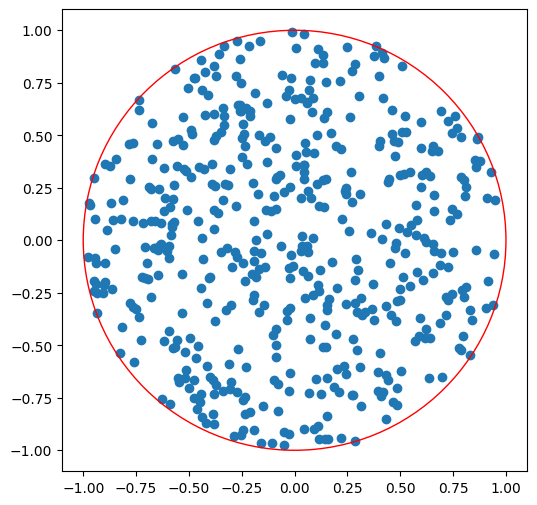

In [223]:
import numpy as np
import matplotlib.pyplot as plt

r=np.sqrt(np.random.rand(500))
fi=2*np.pi*np.random.rand(500)
x=r*np.cos(fi)
y=r*np.sin(fi)

plt.figure(figsize=(6, 6))
plt.scatter(x, y)
plt.gca().add_patch(plt.Circle((0, 0), 1, color='r', fill=False))
plt.show()

### Задача 9
Докажите (устно), что приведенный ниже алгоритм (Box-Muller algorithm) формирует выборку из независимых N(0,1) случаных величин. Модифицируйте метод, чтобы исключить вызовы тригонометрических функций ```np.sin``` и ```np.cos```. С помощью модифицированного метода смоделируйте выборку объема 1000 из двумерного гауссовского распределения со средним [4, 7] и ковариационной матрицей [[20,  -4],
       [ -4, 40]]. Постройте 2D гистограмму полученного распределения. Сравните выборочное среднее и ковариационную матрицу с точными значениями.

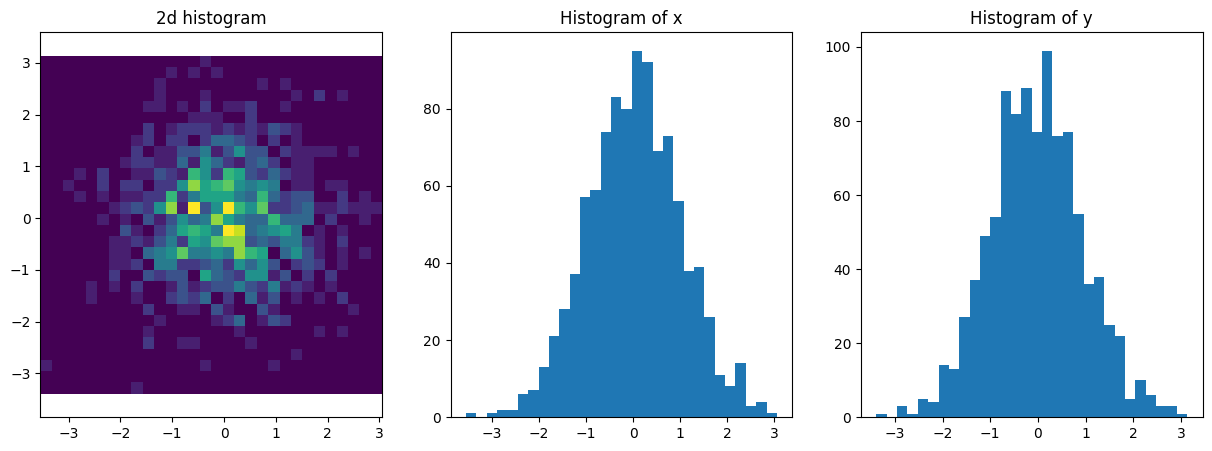

In [257]:
%matplotlib inline

n = 1000
u1, u2 = np.random.rand(2, n)
r = np.sqrt(-2 * np.log(u1))
theta = 2 * np.pi * u2
x = r * np.cos(theta)
y = r * np.sin(theta)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('xkcd:white')
ax[0].hist2d(x, y, bins=30)
ax[0].axis('equal')
ax[1].hist(x, bins=30)
ax[2].hist(y, bins=30)
ax[0].set_title("2d histogram")
ax[1].set_title("Histogram of x")
ax[2].set_title("Histogram of y")
plt.show()

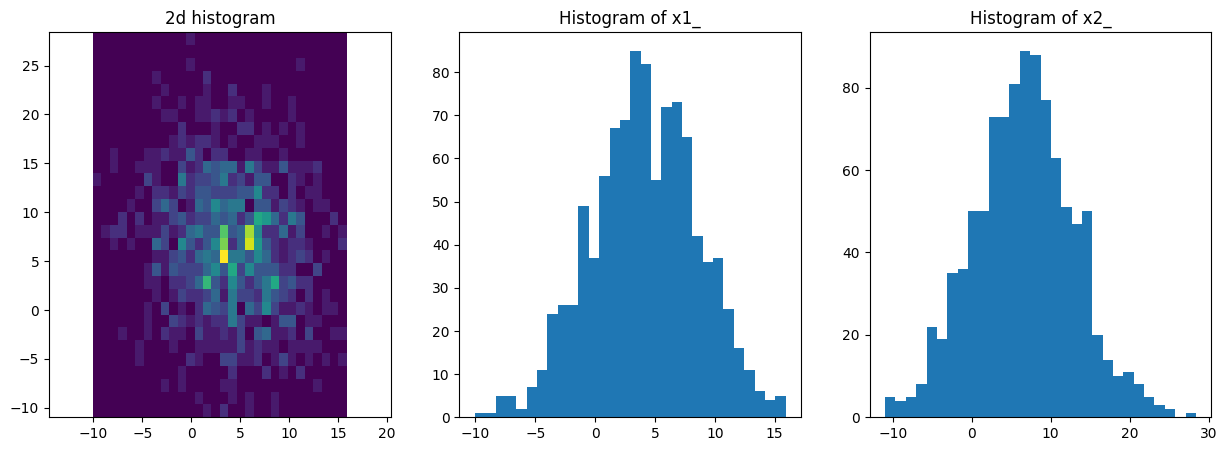

Sample mean: [ 4.140252455926616 , 6.604834312346627 ]


Covariance matrix:
[[19.75972659 -4.20944405]
 [-4.20944405 40.08770675]]


In [258]:
%matplotlib inline

n = 1000
u1, u2 = np.random.rand(2, n)*2-1
for i in range(n):
  while (u1[i]**2+u2[i]**2)>1:
    u1[i]=np.random.rand()*2-1
    u2[i]=np.random.rand()*2-1
s=u1**2+u2**2
s2=np.sqrt(-2*np.log(s)/s)
x1=s2*u1
x2=s2*u2
x1_=4+x1*(-2)+x2*4
x2_=7+x1*6+x2*2

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('xkcd:white')
ax[0].hist2d(x1_, x2_, bins=30)
ax[0].axis('equal')
ax[1].hist(x1_, bins=30)
ax[2].hist(x2_, bins=30)
ax[0].set_title("2d histogram")
ax[1].set_title("Histogram of x1_")
ax[2].set_title("Histogram of x2_")
plt.show()

print("Sample mean: [", np.mean(x1_), ",", np.mean(x2_), "]")
print("\n")
print("Covariance matrix:")
print(np.cov(x1_, x2_))